# Calibration Framework Tutorial

This tutorial shows how to use QuantStrata’s **calibration framework** end-to-end:

- A quick **toy problem** to understand the `CalibrationEngine` API
- **Heston** calibration to a small implied-vol surface (with clean visuals)
- **Hull-White** calibration to synthetic swaption/cap vol data (with visuals)
- **SABR (IR)** smile calibration and diagnostics

The emphasis is on a **professional workflow**:

- Define data and objective
- Choose optimizer and bounds
- Run calibration
- Validate fit visually (surface heatmaps, smiles, error panels)
- Inspect diagnostics

> Notes
> - The examples use **small grids** to keep runtime reasonable.
> - Heston calibration is **non-convex**; different parameter sets can fit similar surfaces.


In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# A small helper for consistent plots
def set_axes(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    return ax

print("Notebook setup complete.")


Notebook setup complete.


## 1) CalibrationEngine fundamentals (toy example)

We start with a simple 2-parameter objective so you can see:

- how to build an objective
- how bounds work
- what `CalibrationResult` returns

Then we visualise the objective landscape and the optimum.


In [2]:
from src.calibration.core.engine import CalibrationEngine
from src.calibration.core.optimizers import LBFGSBConfig

# Toy objective: (x-1)^2 + (y-2)^2

def toy_objective(p: np.ndarray) -> float:
    x, y = float(p[0]), float(p[1])
    return (x - 1.0) ** 2 + (y - 2.0) ** 2

engine = CalibrationEngine(optimizer=LBFGSBConfig(max_iter=200, tol=1e-12))
result = engine.calibrate(
    objective=toy_objective,
    initial_params=np.array([0.0, 0.0]),
    bounds=[(-5.0, 5.0), (-5.0, 5.0)],
    param_names=["x", "y"],
)

result


CalibrationResult(params=array([1., 2.]), objective_value=4.9917047602712125e-17, success=True, n_iterations=2, n_function_evals=12, message='CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL', elapsed_time=0.0035924999974668026, initial_params=array([0., 0.]), initial_objective=5.0)

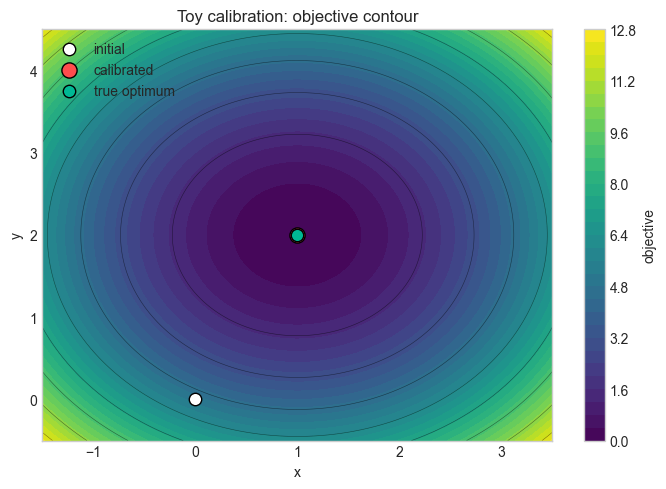

In [3]:
# Visualise the objective landscape
xg = np.linspace(-1.5, 3.5, 200)
yg = np.linspace(-0.5, 4.5, 200)
X, Y = np.meshgrid(xg, yg)
Z = (X - 1.0) ** 2 + (Y - 2.0) ** 2

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contourf(X, Y, Z, levels=40, cmap="viridis")
ax.contour(X, Y, Z, levels=10, colors="k", linewidths=0.4, alpha=0.5)

ax.scatter([0.0], [0.0], s=80, c="white", edgecolor="black", label="initial")
ax.scatter([result.params[0]], [result.params[1]], s=120, c="#ff4d4d", edgecolor="black", label="calibrated")
ax.scatter([1.0], [2.0], s=80, c="#00b894", edgecolor="black", label="true optimum")

set_axes(ax, title="Toy calibration: objective contour", xlabel="x", ylabel="y")
fig.colorbar(cs, ax=ax, label="objective")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 2) Heston calibration to an implied-vol surface

We calibrate Heston parameters to a small **synthetic** `GridVolSurface`:

1. Generate a surface from known Heston parameters
2. Calibrate back to that surface
3. Visualise:
   - Market vs model surface (heatmaps)
   - Error surface (heatmap)
   - Smiles by expiry (line charts)

This is the typical workflow you’ll use in production: replace the synthetic surface with market data.


In [4]:
from src.marketdata.surfaces.vol_surface import GridVolSurface
from src.models.stochastic_volatility.heston import HestonParameters, heston_implied_vol_surface
from src.calibration.stochastic_volatility.heston import calibrate_heston_to_surface, HestonCalibrationConfig

# Synthetic "market" surface settings
spot = 100.0
r, q = 0.03, 0.01

expiries = np.array([0.25, 0.5, 1.0])
strikes = np.array([85, 90, 95, 100, 105, 110, 115], dtype=float)

true_params = HestonParameters(
    kappa=2.0,
    theta=0.04,
    xi=0.5,
    v0=0.04,
    rho=-0.6,
)

market_vols = heston_implied_vol_surface(true_params, spot, r, q, strikes, expiries)

surface = GridVolSurface(
    expiries=expiries,
    strikes=strikes,
    implied_vols=market_vols,
    surface_id="SYNTHETIC.HESTON",
)

surface, true_params


(GridVolSurface(expiries=array([0.25, 0.5 , 1.  ]), strikes=array([ 85.,  90.,  95., 100., 105., 110., 115.]), implied_vols=array([[0.001     , 0.20780792, 0.28106829, 0.31540138, 0.33540929,
         0.34669848, 0.35119841],
        [0.001     , 0.20190523, 0.23443663, 0.25290392, 0.26440348,
         0.2712824 , 0.27449556],
        [0.19927612, 0.20853796, 0.21585879, 0.2213391 , 0.22521874,
         0.22768283, 0.22883864]]), extrapolation='flat', strike_space='absolute', surface_id='SYNTHETIC.HESTON'),
 HestonParameters(kappa=2.0, theta=0.04, xi=0.5, v0=0.04, rho=-0.6))

In [5]:
# Calibrate Heston
cfg = HestonCalibrationConfig(
    fix_v0_to_atm=True,
    enforce_feller=True,
    feller_penalty_weight=2000.0,
    use_global_optimizer=False,  # keep runtime reasonable for tutorial
    max_iter=250,
    tol=1e-10,
    verbose=False,
)

heston_fit = calibrate_heston_to_surface(
    surface=surface,
    spot=spot,
    r=r,
    q=q,
    config=cfg,
    use_subset=False,
)

print(heston_fit)


HestonCalibrationResult
  κ (kappa) = 9.9992
  θ (theta) = 0.023493 (long-term vol = 15.33%)
  ξ (xi)    = 0.0100
  V₀ (v0)   = 0.099478 (initial vol = 31.54%)
  ρ (rho)   = -0.6889
  Feller satisfied: True
  RMSE: 0.0106 (1.06%)
  Max error: 0.0254 (2.54%)
  Converged: True


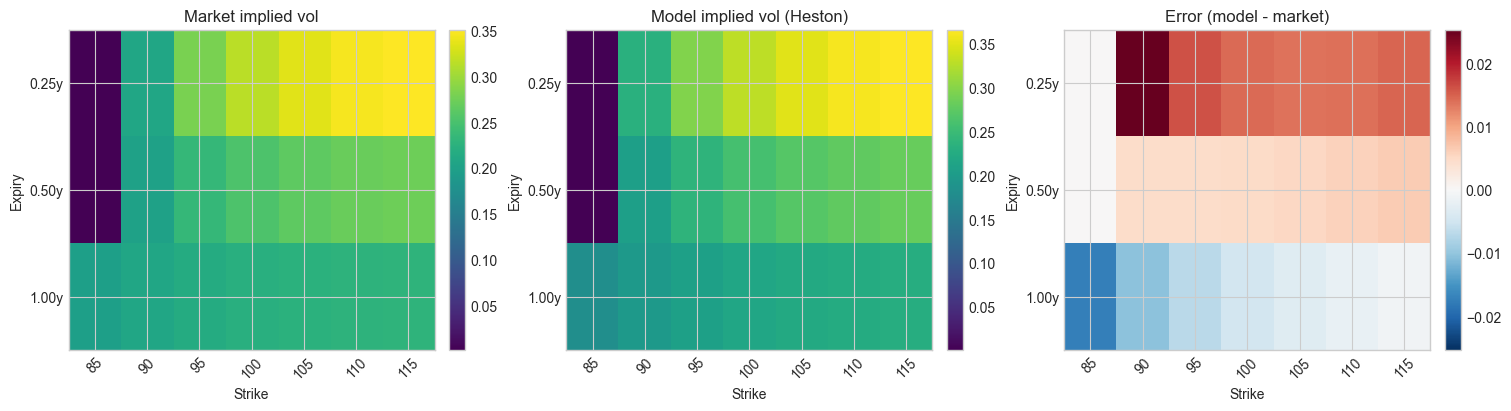

RMSE: 0.0106  |  Max abs error: 0.0254


In [6]:
# Visual diagnostics: surfaces + errors
market = heston_fit.market_vols
model = heston_fit.model_vols
err = model - market

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(market, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(strikes)))
axes[0].set_xticklabels([f"{k:.0f}" for k in strikes], rotation=45)
axes[0].set_yticks(range(len(expiries)))
axes[0].set_yticklabels([f"{t:.2f}y" for t in expiries])
set_axes(axes[0], title="Market implied vol", xlabel="Strike", ylabel="Expiry")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(model, aspect="auto", cmap="viridis")
axes[1].set_xticks(range(len(strikes)))
axes[1].set_xticklabels([f"{k:.0f}" for k in strikes], rotation=45)
axes[1].set_yticks(range(len(expiries)))
axes[1].set_yticklabels([f"{t:.2f}y" for t in expiries])
set_axes(axes[1], title="Model implied vol (Heston)", xlabel="Strike", ylabel="Expiry")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Symmetric diverging scale for errors
m = np.max(np.abs(err))
im2 = axes[2].imshow(err, aspect="auto", cmap="RdBu_r", vmin=-m, vmax=m)
axes[2].set_xticks(range(len(strikes)))
axes[2].set_xticklabels([f"{k:.0f}" for k in strikes], rotation=45)
axes[2].set_yticks(range(len(expiries)))
axes[2].set_yticklabels([f"{t:.2f}y" for t in expiries])
set_axes(axes[2], title="Error (model - market)", xlabel="Strike", ylabel="Expiry")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

print(f"RMSE: {heston_fit.rmse:.4f}  |  Max abs error: {heston_fit.max_error:.4f}")


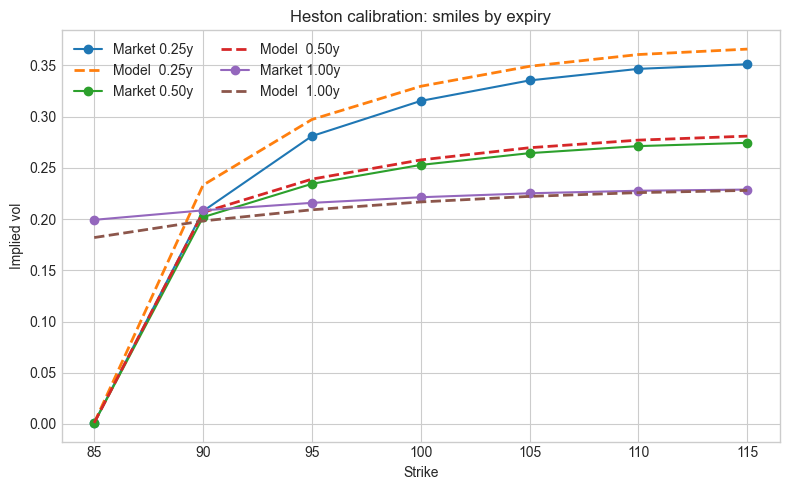

In [7]:
# Visual diagnostics: smiles by expiry
fig, ax = plt.subplots(figsize=(8, 5))

for i, T in enumerate(expiries):
    ax.plot(strikes, market[i], marker="o", linewidth=1.5, label=f"Market {T:.2f}y")
    ax.plot(strikes, model[i], linestyle="--", linewidth=2.0, label=f"Model  {T:.2f}y")

set_axes(ax, title="Heston calibration: smiles by expiry", xlabel="Strike", ylabel="Implied vol")
ax.legend(ncols=2)
plt.tight_layout()
plt.show()


## 3) Hull-White calibration (rates) — synthetic swaptions & caps

This section demonstrates a **rates-style** calibration workflow.

We’ll:
- Build a simple flat discount curve function `df(t)`
- Create synthetic swaption and cap vol quotes
- Calibrate Hull-White parameters `a` and `sigma`
- Visualise the fit as heatmaps and term-structure plots

> Note: Hull-White is a **single-factor** model, so it will not fit full smiles; here we use ATM-like inputs.


In [8]:
from src.calibration.short_rate.hull_white import (
    calibrate_hull_white_to_swaptions,
    calibrate_hull_white_to_caps,
    HullWhiteCalibrationConfig,
)

# Flat discount curve
r0 = 0.03

def df(t: float) -> float:
    return float(np.exp(-r0 * float(t)))

# Synthetic swaption vols (normal vols)
expiries_hw = np.array([1.0, 2.0, 5.0, 10.0])
tenors_hw = np.array([5.0, 10.0])
market_swaption_vols = np.array([
    [0.0048, 0.0052],
    [0.0050, 0.0054],
    [0.0053, 0.0056],
    [0.0056, 0.0059],
])

hw_cfg = HullWhiteCalibrationConfig(max_iter=250, tol=1e-10, verbose=False)

hw_swaption_fit = calibrate_hull_white_to_swaptions(
    swaption_vols=market_swaption_vols,
    expiries=expiries_hw,
    tenors=tenors_hw,
    yield_curve_df=df,
    r0=r0,
    config=hw_cfg,
)

print(hw_swaption_fit)


HullWhiteCalibrationResult
  a (mean reversion) = 0.1000
  σ (volatility)     = 0.0054 (53.5 bp)
  Half-life: 6.93 years
  RMSE: 0.000332
  Max error: 0.000550
  Converged: True


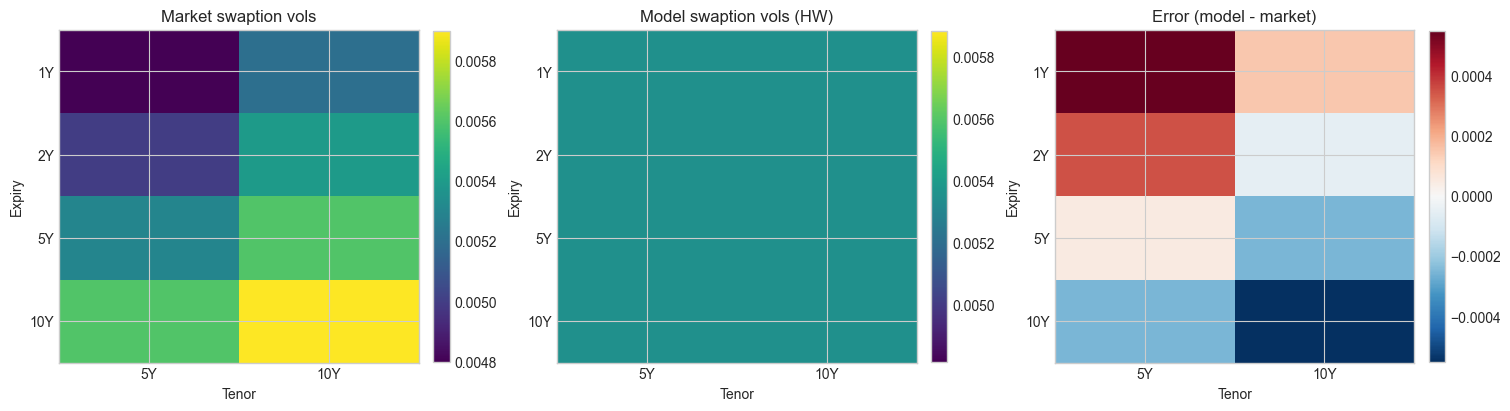

Swaption RMSE: 0.000332


In [9]:
# Swaption fit heatmaps
mkt = hw_swaption_fit.market_vols
mdl = hw_swaption_fit.model_vols
err = mdl - mkt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(mkt, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(tenors_hw)))
axes[0].set_xticklabels([f"{t:.0f}Y" for t in tenors_hw])
axes[0].set_yticks(range(len(expiries_hw)))
axes[0].set_yticklabels([f"{t:.0f}Y" for t in expiries_hw])
set_axes(axes[0], title="Market swaption vols", xlabel="Tenor", ylabel="Expiry")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(mdl, aspect="auto", cmap="viridis")
axes[1].set_xticks(range(len(tenors_hw)))
axes[1].set_xticklabels([f"{t:.0f}Y" for t in tenors_hw])
axes[1].set_yticks(range(len(expiries_hw)))
axes[1].set_yticklabels([f"{t:.0f}Y" for t in expiries_hw])
set_axes(axes[1], title="Model swaption vols (HW)", xlabel="Tenor", ylabel="Expiry")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

mmax = np.max(np.abs(err))
im2 = axes[2].imshow(err, aspect="auto", cmap="RdBu_r", vmin=-mmax, vmax=mmax)
axes[2].set_xticks(range(len(tenors_hw)))
axes[2].set_xticklabels([f"{t:.0f}Y" for t in tenors_hw])
axes[2].set_yticks(range(len(expiries_hw)))
axes[2].set_yticklabels([f"{t:.0f}Y" for t in expiries_hw])
set_axes(axes[2], title="Error (model - market)", xlabel="Tenor", ylabel="Expiry")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

print(f"Swaption RMSE: {hw_swaption_fit.rmse:.6f}")


HullWhiteCalibrationResult
  a (mean reversion) = 0.1000
  σ (volatility)     = 0.0051 (51.0 bp)
  Half-life: 6.93 years
  RMSE: 0.000406
  Max error: 0.000600
  Converged: True


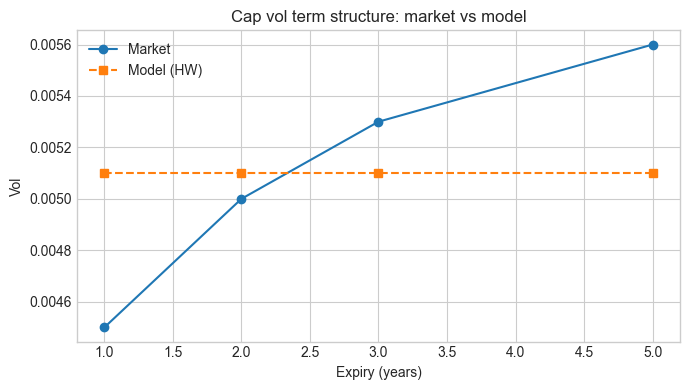

In [10]:
# Cap calibration (synthetic term structure)
expiries_cap = np.array([1.0, 2.0, 3.0, 5.0])
market_cap_vols = np.array([0.0045, 0.0050, 0.0053, 0.0056])

hw_cap_fit = calibrate_hull_white_to_caps(
    cap_vols=market_cap_vols,
    expiries=expiries_cap,
    yield_curve_df=df,
    r0=r0,
    config=HullWhiteCalibrationConfig(max_iter=250, tol=1e-10, verbose=False),
)

print(hw_cap_fit)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(expiries_cap, market_cap_vols, marker="o", label="Market")
ax.plot(expiries_cap, hw_cap_fit.model_vols.reshape(-1), linestyle="--", marker="s", label="Model (HW)")
set_axes(ax, title="Cap vol term structure: market vs model", xlabel="Expiry (years)", ylabel="Vol")
ax.legend()
plt.tight_layout()
plt.show()


## 4) SABR (IR) swaption smile calibration

Here we calibrate SABR to a swaption smile and visualise:

- Market smile vs fitted SABR smile
- Residuals by strike

This is how you would fit per 
- (expiry, tenor) point (cube), or
- a single smile slice.


SabrParameters(alpha=0.00014472718022774783, beta=0.0, rho=0.008383668967024593, nu=0.005049549401562573)


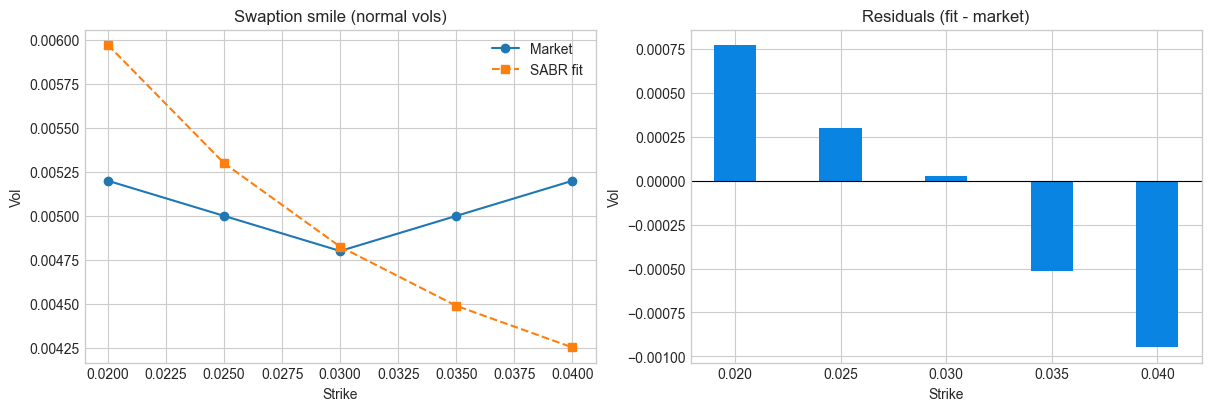

In [11]:
from src.calibration.volatility_surface.sabr import (
    calibrate_sabr_to_swaption_smile,
    sabr_implied_vol,
    SabrConfig,
)

F = 0.03
T = 10.0
TENOR = 10.0

K = np.array([0.02, 0.025, 0.03, 0.035, 0.04])
market = np.array([0.0052, 0.0050, 0.0048, 0.0050, 0.0052])

params = calibrate_sabr_to_swaption_smile(
    strikes=K,
    market_vols=market,
    forward_swap_rate=F,
    expiry=T,
    tenor=TENOR,
    vol_type="normal",
    config=SabrConfig(beta=0.0, max_iter=500, tol=1e-12),
)

fit = np.array([sabr_implied_vol(forward=F, strike=k, expiry=T, params=params) for k in K])
res = fit - market

print(params)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(K, market, marker="o", label="Market")
axes[0].plot(K, fit, linestyle="--", marker="s", label="SABR fit")
set_axes(axes[0], title="Swaption smile (normal vols)", xlabel="Strike", ylabel="Vol")
axes[0].legend()

axes[1].bar(K, res, width=0.002, color="#0984e3")
set_axes(axes[1], title="Residuals (fit - market)", xlabel="Strike", ylabel="Vol")
axes[1].axhline(0.0, color="black", linewidth=0.8)

plt.show()


## 5) Practical checklist

When calibrating to real market data:

- **Data hygiene**: filter bad quotes, ensure units (normal vs lognormal) are consistent
- **Bounds**: ensure economically sensible ranges (and avoid “flat directions”)
- **Initial guesses**: use previous-day parameters for stability
- **Diagnostics**: always plot market vs model and error heatmaps
- **Robustness**: for non-convex models (Heston), use **global + local** optimization for production

Next steps you can add:

- Store/load calibration results as artifacts
- Add per-slice calibrations (e.g., Heston per-expiry or SABR cube) + smoothing
- Add shifted-SABR to support negative forwards cleanly
